In [1]:
def f(z0, c, max_iter):
    zi = z0
    n_iter = 0
    diverge = False
    while n_iter < max_iter:
        zi = zi*zi + c
        try:
            if np.isinf(abs(zi)):
                diverge = True
                break
        except OverflowError:
            diverge = True
            break
        n_iter += 1
    
    return  diverge, n_iter

/tmp/ipykernel_40115/1027701127.py:6: RuntimeWarning: overflow encountered in cdouble_scalars
  zi = zi*zi + c
/tmp/ipykernel_40115/1027701127.py:6: RuntimeWarning: invalid value encountered in cdouble_scalars
  zi = zi*zi + c


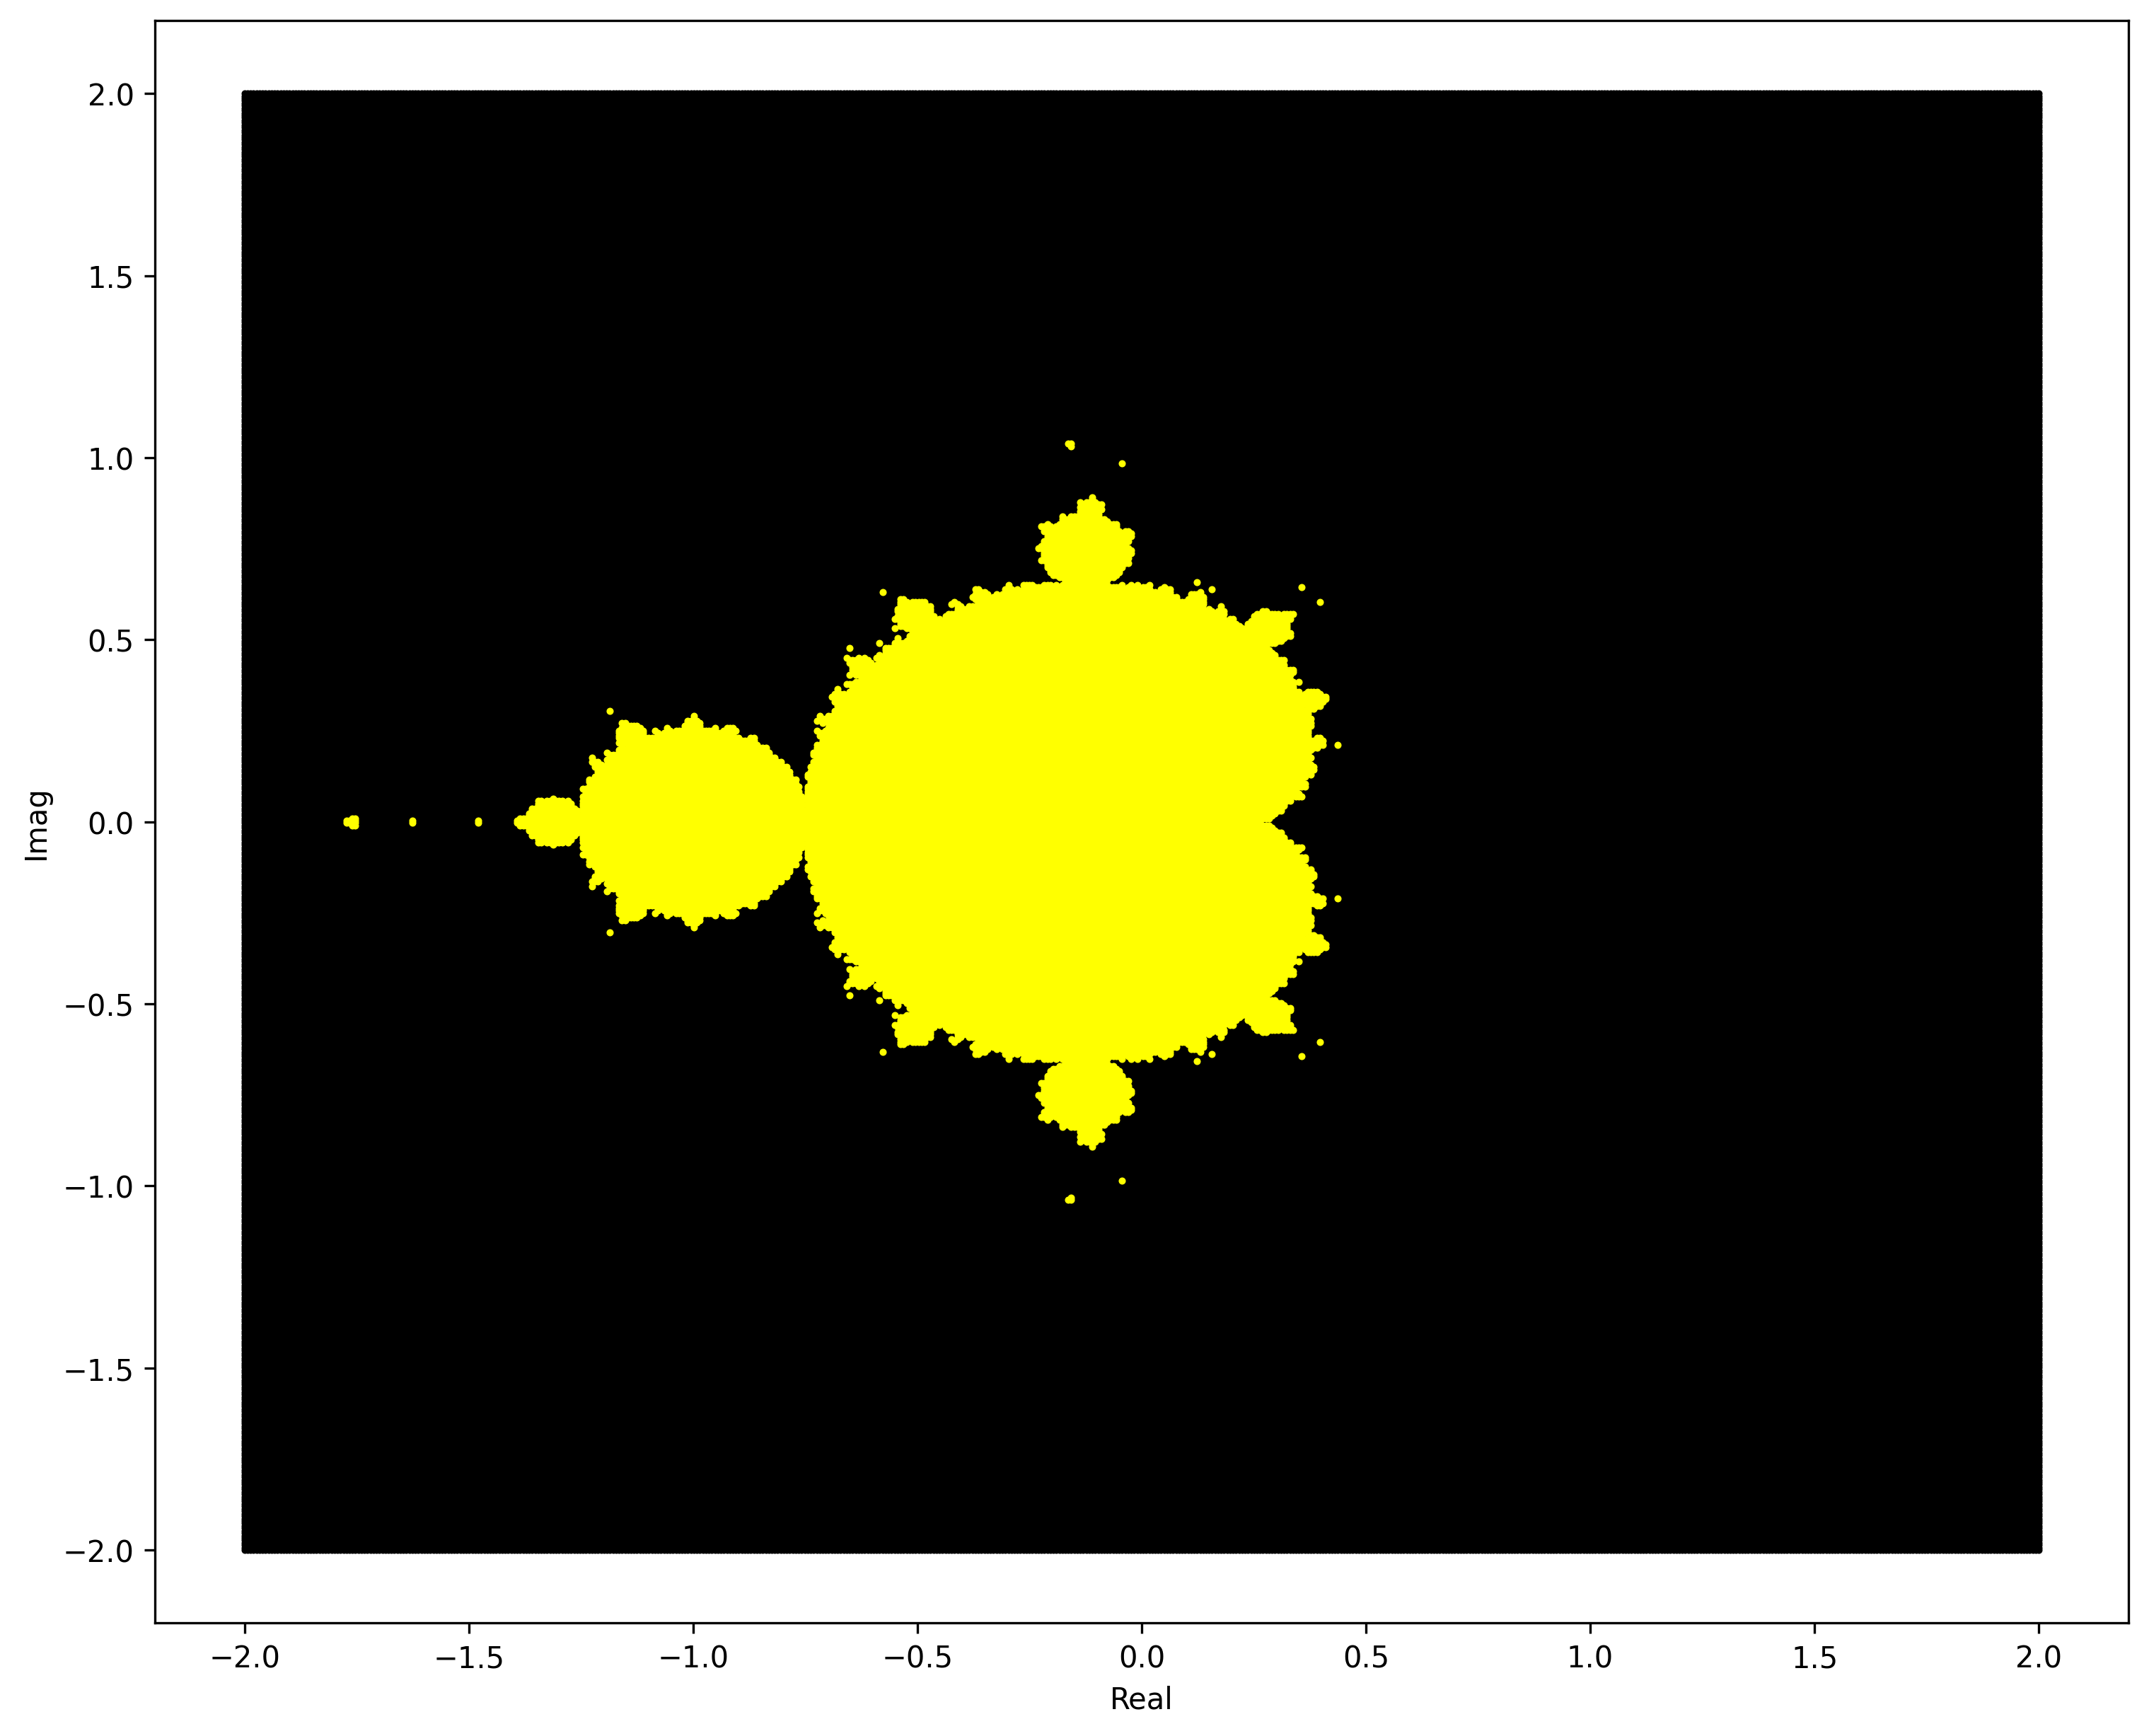

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


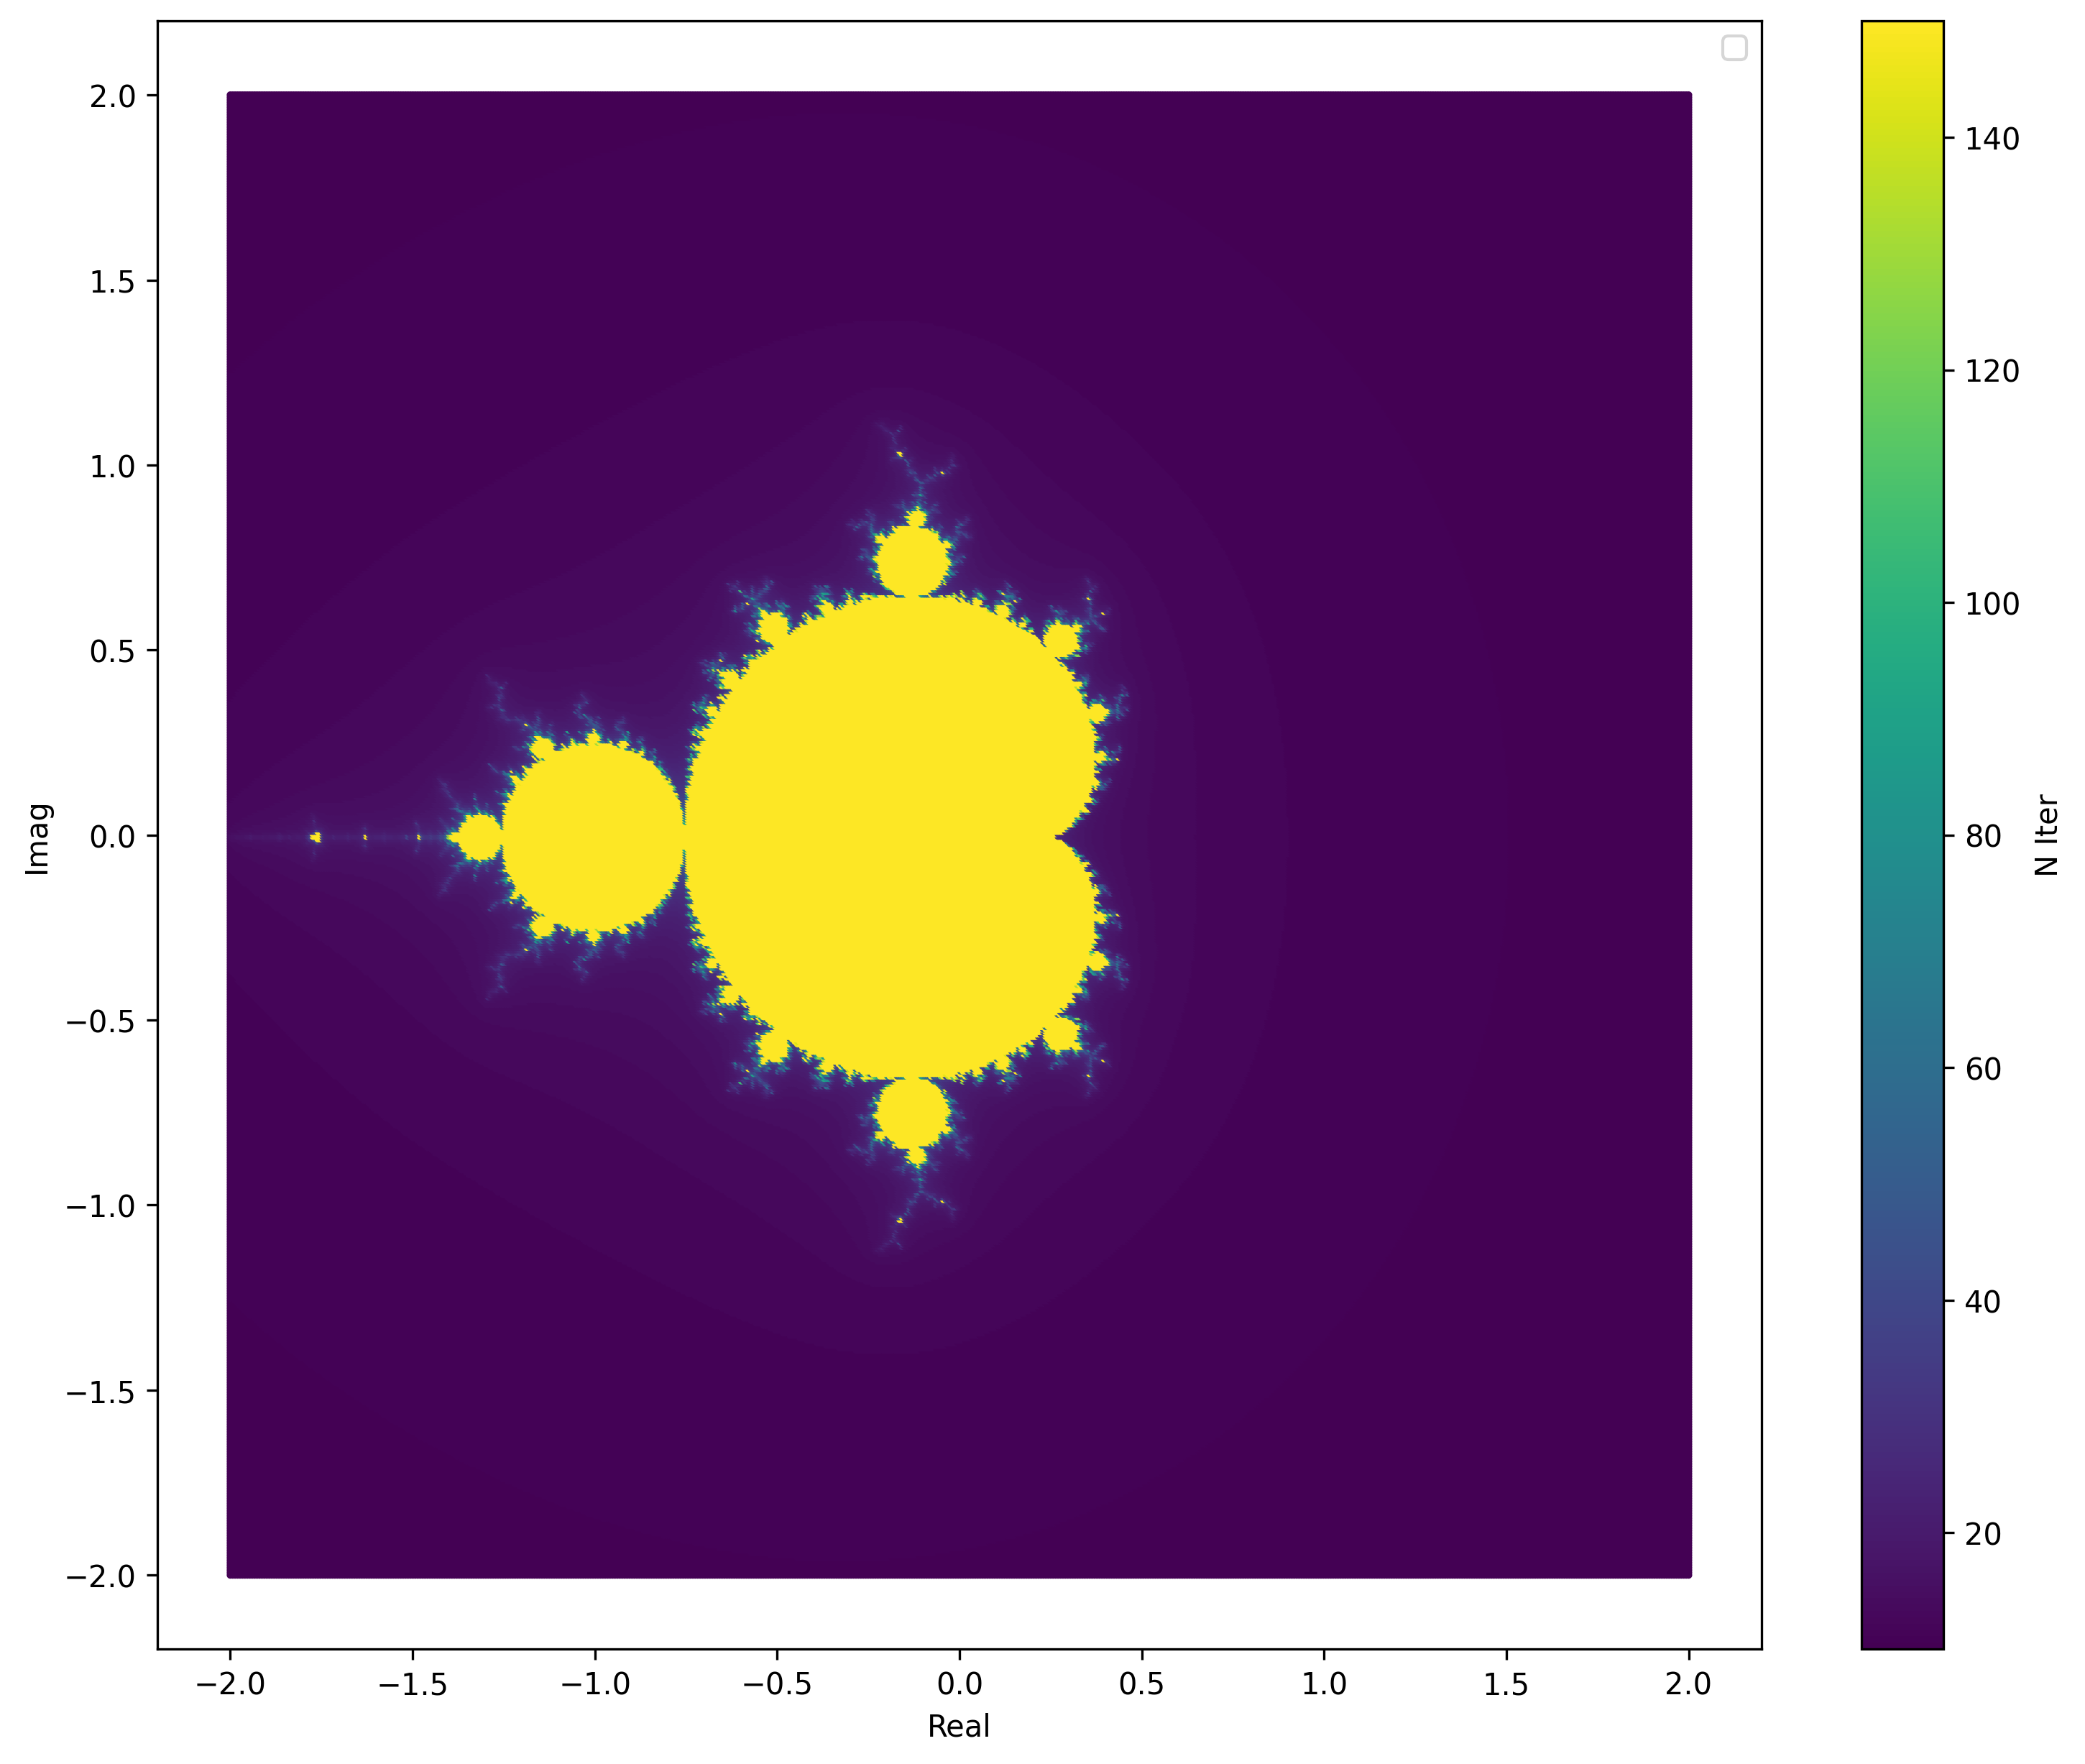

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import traceback

z0 = 0
x = np.linspace(-2, 2, 600)
y = np.linspace(-2, 2, 600)
x, y = np.meshgrid(x, y)
complex_n = x + 1j * y

vectorized_f = np.vectorize(f)
results = vectorized_f(0, complex_n, 150)

diverge_lst = results[0]
n_iter_lst = results[1]

diverge_c = complex_n[diverge_lst]
converge_c = complex_n[~diverge_lst]

plt.figure(figsize=(12, 10), dpi=300)
plt.scatter(diverge_c.real, diverge_c.imag, c='black', s=2)
plt.scatter(converge_c.real, converge_c.imag, c='yellow', s=2)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.show()

plt.figure(figsize=(12, 10), dpi=300)
plt.scatter(complex_n.real, complex_n.imag, c=n_iter_lst, s=2)
plt.colorbar(label='N Iter')
plt.xlabel('Real')
plt.ylabel('Imag')
plt.legend()
plt.show()